# DATASET DOWNLOAD

In [ ]:
from huggingface_hub import login, hf_hub_download
import os


print(" Logging into Hugging Face...")
login(token='') 

print(" Downloading datasets...")

hf_hub_download(
    repo_id="Harsh2005/DeepFashion2-Pruned", 
    filename="train_clean.zip", 
    repo_type="dataset", 
    local_dir="/kaggle/working"
)

hf_hub_download(
    repo_id="Harsh2005/DeepFashion2-Pruned", 
    filename="validation_clean.zip", 
    repo_type="dataset", 
    local_dir="/kaggle/working"
)

print(" Unzipping files...")
!unzip -q /kaggle/working/train_clean.zip -d /kaggle/working/train
!unzip -q /kaggle/working/validation_clean.zip -d /kaggle/working/val


import os


    

print("✅ Data is ready!")

 Logging into Hugging Face...


train_clean.zip:   0%|          | 0.00/7.99G [00:00<?, ?B/s]

validation_clean.zip:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

 Unzipping files...
✅ Data is ready!


In [2]:

if os.path.exists("/kaggle/working/train_clean.zip"):
    os.remove("/kaggle/working/train_clean.zip")
    print(" Deleted train_clean.zip")

if os.path.exists("/kaggle/working/validation_clean.zip"):
    os.remove("/kaggle/working/validation_clean.zip")
    print(" Deleted validation_clean.zip")

 Deleted train_clean.zip
 Deleted validation_clean.zip


# TASK 3.1 : CLASSIFICATION

## Data Preprocessing

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import json
import os
from glob import glob


CATEGORIES = ["short sleeve top", "trousers", "shorts", "long sleeve top", "skirt"]
CAT_TO_IDX = {cat: i for i, cat in enumerate(CATEGORIES)}


class DeepFashionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.json_paths = glob(os.path.join(root_dir, '**/*.json'), recursive=True)
        
    def __len__(self): 
        return len(self.json_paths)

    def __getitem__(self, idx):
        json_path = self.json_paths[idx]
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        
        labels = torch.zeros(len(CATEGORIES), dtype=torch.float32)
        for key, value in data.items():
            if key.startswith('item') and isinstance(value, dict):
                cat_name = value.get('category_name')
                if cat_name in CAT_TO_IDX:
                    labels[CAT_TO_IDX[cat_name]] = 1.0
        
        
        img_path = json_path.replace('.json', '.jpg').replace('annos', 'image')
        if not os.path.exists(img_path):
            img_path = json_path.replace('.json', '.jpg')
        
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labels


train_ts = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(15),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_ts = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


train_set = DeepFashionDataset('/kaggle/working/train/train', train_ts)
val_set = DeepFashionDataset('/kaggle/working/val/validation', val_ts)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)

print(f"✅ Setup Complete.")
print(f"Found {len(train_set)} training samples and {len(val_set)} validation samples.")

✅ Setup Complete.
Found 144174 training samples and 23741 validation samples.


## Evaluation Metrics

In [4]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import numpy as np

def calculate_metrics(y_true, y_prob):
    # Threshold at 0.5 for classification 
    y_pred = (y_prob > 0.5).astype(int)
    
    # Per-class and averaged F1-scores 
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)[2]
 
    auc_scores = []
    for i in range(y_true.shape[1]):
        try:
            auc_scores.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
        except ValueError:
            auc_scores.append(0.5) 
            
    return precision, recall, f1, micro_f1, auc_scores

def validate(model, loader, criterion, device):
    model.eval()
    all_labels, all_preds, val_loss = [], [], 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            all_labels.append(labels.cpu())
            all_preds.append(torch.sigmoid(outputs).cpu())
            
    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_preds).numpy()
    
    prec, rec, f1_ma, f1_mi, aucs = calculate_metrics(y_true, y_prob)
    return val_loss/len(loader), f1_ma, f1_mi, aucs

## Model traning

### Scratch

In [5]:
import torch
from torchvision import models
import torch.nn as nn
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
strategy = "scratch" 

# 1. Load empty model
model = models.resnet50(weights=None) 

# 2. Standard Final Layer
model.fc = nn.Linear(model.fc.in_features, len(CATEGORIES))
model = model.to(device)

pos_weight_tensor = torch.tensor([1.01, 1.60, 2.93, 2.99, 3.67]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 15 
best_val_loss = float('inf')
patience, patience_counter = 3, 0 

print(f"Starting V3 {strategy} training (No Dropout)...")

for epoch in range(1, epochs + 1):
    model.train()
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
    
    v_loss, f1_ma, f1_mi, aucs = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch} | Val Loss: {v_loss:.4f} | Macro-F1: {f1_ma:.4f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"resnet50_{strategy}.pth")
        print("   -> New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered. Model stopped improving.")
            break

Starting V3 scratch training (No Dropout)...


Epoch 1/15: 100%|██████████| 2253/2253 [12:01<00:00,  3.12it/s]


Epoch 1 | Val Loss: 0.8037 | Macro-F1: 0.5692
   -> New best model saved!


Epoch 2/15: 100%|██████████| 2253/2253 [11:52<00:00,  3.16it/s]


Epoch 2 | Val Loss: 0.6800 | Macro-F1: 0.6426
   -> New best model saved!


...

Epoch 13 | Val Loss: 0.4053 | Macro-F1: 0.8041
   -> New best model saved!


Epoch 14/15: 100%|██████████| 2253/2253 [11:56<00:00,  3.14it/s]


Epoch 14 | Val Loss: 0.3890 | Macro-F1: 0.8138
   -> New best model saved!


Epoch 15/15: 100%|██████████| 2253/2253 [11:56<00:00,  3.15it/s]


Epoch 15 | Val Loss: 0.3992 | Macro-F1: 0.8111


### Transfer Learning

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
strategy = "transfer"

model = models.resnet50(weights='IMAGENET1K_V1')

# Freeze the base layers
for param in model.parameters():
    param.requires_grad = False

# Standard Final Layer
model.fc = nn.Linear(model.fc.in_features, len(CATEGORIES))
model = model.to(device)

pos_weight_tensor = torch.tensor([1.01, 1.60, 2.93, 2.99, 3.67]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor) 

# Optimize ONLY the fully connected block
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 10 
best_val_loss = float('inf')
patience, patience_counter = 3, 0

print(f"Starting V3 {strategy} training (No Dropout)...")

for epoch in range(1, epochs + 1):
    model.train()
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
    
    v_loss, f1_ma, f1_mi, aucs = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch} | Val Loss: {v_loss:.4f} | Macro-F1: {f1_ma:.4f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"resnet50_{strategy}.pth")
        print("   -> New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Starting V3 transfer training (No Dropout)...


Epoch 1/10: 100%|██████████| 2253/2253 [10:50<00:00,  3.46it/s]


Epoch 1 | Val Loss: 0.6919 | Macro-F1: 0.6243
   -> New best model saved!


...

Epoch 6 | Val Loss: 0.6903 | Macro-F1: 0.6191


Epoch 7/10: 100%|██████████| 2253/2253 [10:52<00:00,  3.45it/s]


Epoch 7 | Val Loss: 0.6903 | Macro-F1: 0.6436


Epoch 8/10: 100%|██████████| 2253/2253 [10:59<00:00,  3.42it/s]


Epoch 8 | Val Loss: 0.6837 | Macro-F1: 0.6409
Early stopping triggered.


### Transfer Learning with Fine Tuning deeper layers

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
strategy = "fine_tune_3_layers" 

model = models.resnet50(weights='IMAGENET1K_V1')

# Unfreeze layer2, layer3, layer4, and fc
for name, param in model.named_parameters():
    if "layer2" in name or "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
        
# Standard Final Layer
model.fc = nn.Linear(model.fc.in_features, len(CATEGORIES))
model = model.to(device)

pos_weight_tensor = torch.tensor([1.01, 1.60, 2.93, 2.99, 3.67]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# L2 Weight decay active
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

epochs = 15
best_val_loss = float('inf')
patience, patience_counter = 4, 0

print(f"Starting V3 Deep Fine-Tuning (3 Layers) (No Dropout)...")

for epoch in range(1, epochs + 1):
    model.train()
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        
    v_loss, f1_ma, f1_mi, aucs = validate(model, val_loader, criterion, device)
    scheduler.step(f1_ma)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch} | LR: {current_lr:.6f} | Val Loss: {v_loss:.4f} | Macro-F1: {f1_ma:.4f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"resnet50_{strategy}.pth")
        print("   -> New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Starting V3 Deep Fine-Tuning (3 Layers) (No Dropout)...


Epoch 1/15: 100%|██████████| 2253/2253 [11:28<00:00,  3.27it/s]


Epoch 1 | LR: 0.000100 | Val Loss: 0.3544 | Macro-F1: 0.8268
   -> New best model saved!


Epoch 2/15: 100%|██████████| 2253/2253 [11:22<00:00,  3.30it/s]


Epoch 2 | LR: 0.000100 | Val Loss: 0.3211 | Macro-F1: 0.8420
   -> New best model saved!


...

Epoch 7 | LR: 0.000100 | Val Loss: 0.3427 | Macro-F1: 0.8561


Epoch 8/15: 100%|██████████| 2253/2253 [11:36<00:00,  3.23it/s]


Epoch 8 | LR: 0.000100 | Val Loss: 0.3356 | Macro-F1: 0.8488


Epoch 9/15: 100%|██████████| 2253/2253 [11:44<00:00,  3.20it/s]


Epoch 9 | LR: 0.000050 | Val Loss: 0.3476 | Macro-F1: 0.8554
Early stopping triggered.



🚀 GENERATING FINAL EVALUATION

📊 Analyzing Strategy: 1. Scratch...


Testing 1. Scratch: 100%|██████████| 371/371 [01:34<00:00,  3.94it/s]



--- 1. Scratch Classification Report ---
                  precision    recall  f1-score   support

short sleeve top       0.90      0.82      0.86     12371
        trousers       0.84      0.93      0.88      9494
          shorts       0.75      0.79      0.77      4133
 long sleeve top       0.64      0.87      0.74      5916
           skirt       0.76      0.88      0.82      6499

       micro avg       0.79      0.86      0.83     38413
       macro avg       0.78      0.86      0.81     38413
    weighted avg       0.81      0.86      0.83     38413
     samples avg       0.81      0.87      0.82     38413


📊 Analyzing Strategy: 2. Transfer...


Testing 2. Transfer: 100%|██████████| 371/371 [01:35<00:00,  3.90it/s]



--- 2. Transfer Classification Report ---
                  precision    recall  f1-score   support

short sleeve top       0.77      0.64      0.70     12371
        trousers       0.67      0.85      0.75      9494
          shorts       0.46      0.66      0.54      4133
 long sleeve top       0.49      0.71      0.58      5916
           skirt       0.54      0.80      0.65      6499

       micro avg       0.61      0.73      0.66     38413
       macro avg       0.59      0.73      0.64     38413
    weighted avg       0.63      0.73      0.67     38413
     samples avg       0.63      0.74      0.65     38413


📊 Analyzing Strategy: 3. Fine-Tuned (3 Layers)...


Testing 3. Fine-Tuned (3 Layers): 100%|██████████| 371/371 [01:35<00:00,  3.89it/s]



--- 3. Fine-Tuned (3 Layers) Classification Report ---
                  precision    recall  f1-score   support

short sleeve top       0.92      0.86      0.89     12371
        trousers       0.88      0.93      0.90      9494
          shorts       0.78      0.86      0.82      4133
 long sleeve top       0.76      0.86      0.81      5916
           skirt       0.81      0.92      0.86      6499

       micro avg       0.85      0.89      0.87     38413
       macro avg       0.83      0.89      0.86     38413
    weighted avg       0.85      0.89      0.87     38413
     samples avg       0.87      0.89      0.86     38413



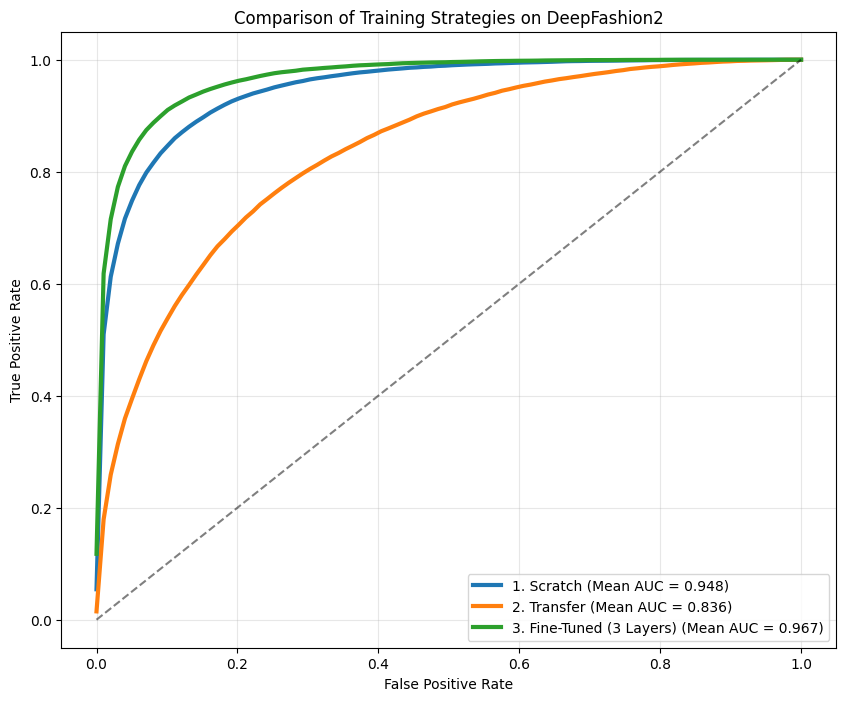


📈 Generating Per-Class ROC for 3. Fine-Tuned (3 Layers)...


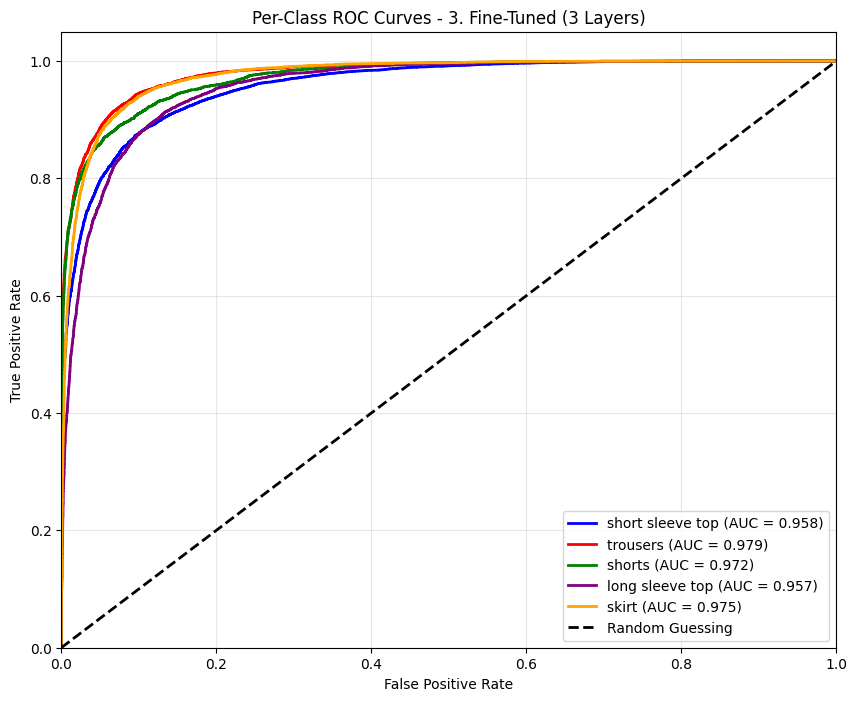

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report
import numpy as np
import torch
from torchvision import models
import torch.nn as nn
from tqdm import tqdm

def generate_ultimate_report(model_configs, loader):
    print(f"\n{'='*40}")
    print("🚀 GENERATING FINAL EVALUATION")
    print(f"{'='*40}")
    
    plt.figure(figsize=(10, 8))
    best_y_true, best_y_prob, best_label = None, None, None
    
    for label, path in model_configs.items():
        print(f"\n📊 Analyzing Strategy: {label}...")
        
        # 1. Load empty ResNet50
        model = models.resnet50(weights=None)
        
        # 2. CRITICAL FIX: Standard Linear layer (NO Sequential/Dropout)
        model.fc = nn.Linear(model.fc.in_features, len(CATEGORIES))
        
        # 3. Load the weights
        model.load_state_dict(torch.load(path))
        model = model.to(device)
        model.eval() 
        
        all_labels, all_probs = [], []
        with torch.no_grad():
            for imgs, labels in tqdm(loader, desc=f"Testing {label}"):
                imgs = imgs.to(device)
                probs = torch.sigmoid(model(imgs)).cpu().numpy()
                all_labels.append(labels.cpu().numpy())
                all_probs.append(probs)
        
        y_true = np.vstack(all_labels)
        y_prob = np.vstack(all_probs)
        y_pred = (y_prob > 0.5).astype(int)
        
        print(f"\n--- {label} Classification Report ---")
        print(classification_report(y_true, y_pred, target_names=CATEGORIES, zero_division=0))
        
        if "Fine-Tuned" in label:
            best_y_true, best_y_prob, best_label = y_true, y_prob, label
        
        fpr_grid = np.linspace(0.0, 1.0, 100)
        mean_tpr = 0.0
        for i in range(len(CATEGORIES)):
            fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
            mean_tpr += np.interp(fpr_grid, fpr, tpr)
        mean_tpr /= len(CATEGORIES)
        mean_auc = auc(fpr_grid, mean_tpr)
        
        plt.plot(fpr_grid, mean_tpr, label=f'{label} (Mean AUC = {mean_auc:.3f})', lw=3)

    # --- PLOT 1: STRATEGY COMPARISON ---
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Comparison of Training Strategies on DeepFashion2')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('final_strategy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # --- PLOT 2: PER-CLASS ROC FOR BEST MODEL ---
    print(f"\n📈 Generating Per-Class ROC for {best_label}...")
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, color in enumerate(colors):
        fpr, tpr, _ = roc_curve(best_y_true[:, i], best_y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{CATEGORIES[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Per-Class ROC Curves - {best_label}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    plt.savefig('per_class_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

results_to_compare = {
    "1. Scratch": "resnet50_scratch.pth",
    "2. Transfer": "resnet50_transfer.pth",
    "3. Fine-Tuned (3 Layers)": "resnet50_fine_tune_3_layers.pth" 
}

generate_ultimate_report(results_to_compare, val_loader)